In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [3]:

df.shape

(200, 2)

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

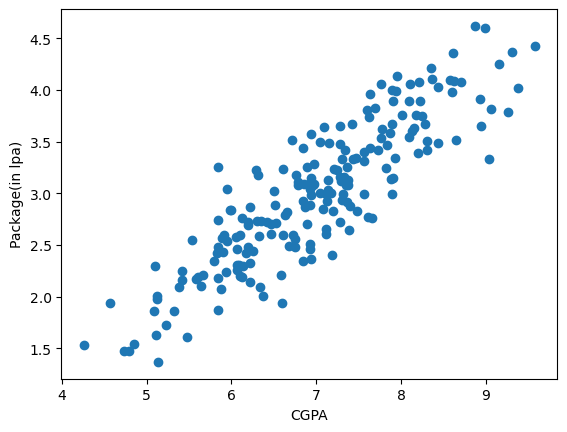

In [5]:

plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [6]:

X = df.iloc[:,0:1]
y = df.iloc[:,-1]

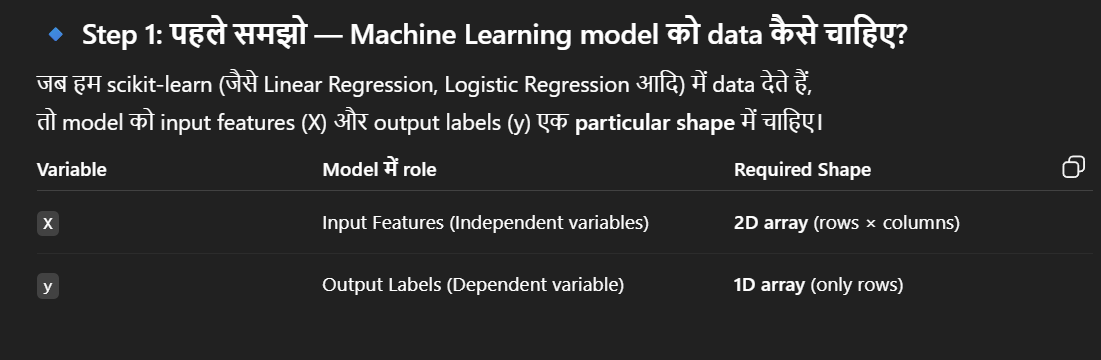

In [7]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [8]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [9]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)  
# अगर तुम random_state fix नहीं करते,
# तो हर बार data अलग-अलग तरीके से split होगा।

In [10]:

from sklearn.linear_model import LinearRegression

In [11]:

lr = LinearRegression()

In [12]:
lr

LinearRegression()

In [13]:

lr.fit(X_train,y_train)

LinearRegression()

In [14]:

X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [18]:
X_test.shape

(40, 1)

In [19]:

y_test  # ye op hai qki jab hum x op me de rahe hai to y op ke roop me aa rha hai 
# x me students ke cgpa diya gya hai aur isi ke anusasr me y me op me diya gaya hai 

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [20]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [24]:
X_test.iloc[0]

cgpa    8.58
Name: 112, dtype: float64

In [26]:

lr.predict(X_test.iloc[0].values.reshape(1,1))  # ise baad me reshape isliye kiya gaya hai qki 
# x_test tumhara 1d me hai but hame data 2d me chaihye isiliye aisa karna pada hai 

C:\Users\vishal vishwakarma\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

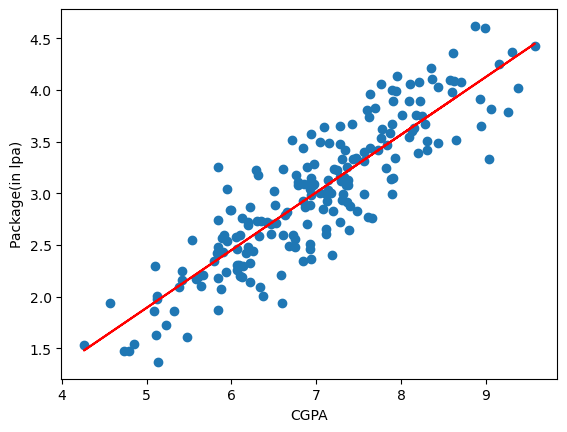

In [27]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [28]:
m = lr.coef_

In [29]:
b = lr.intercept_

In [36]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [38]:

# y = mx + b

m * 7.82 + b  # ye hum check kr rhe hai ki 8.58 cgpa wale ka package kitna laga hoga

# abhi model predict karne me jyaada galti kar raha hai 

array([3.46707251])

In [34]:

m * 9.5 + b

array([4.40443183])

In [35]:

m * 100 + b

array([54.89908542])

## PART -2

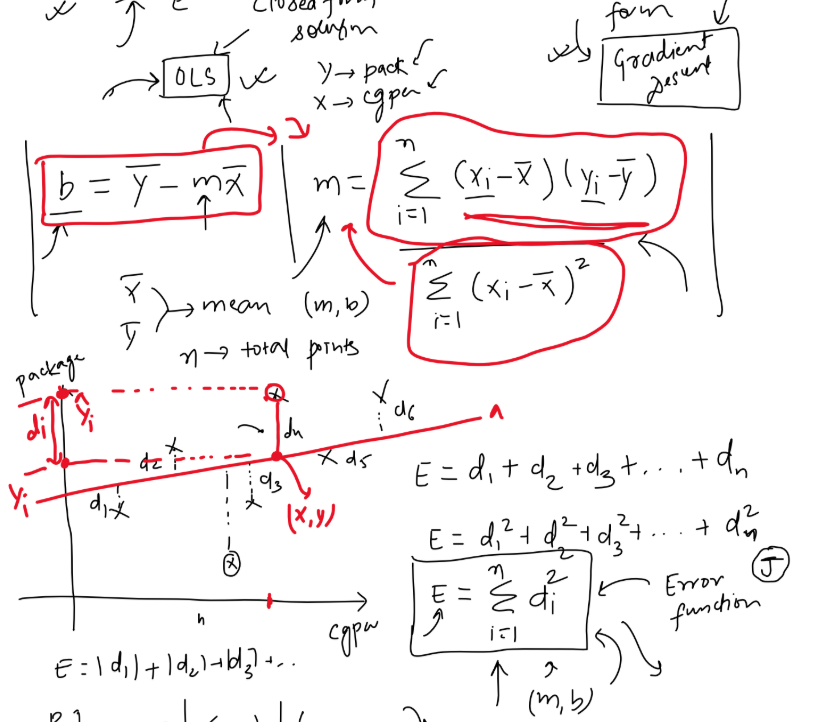

In [39]:
X_train[0:10]

,cgpa
137,7.14
163,8.93
111,5.42
123,5.10
109,7.77
141,6.76
41,6.89
130,6.68
140,7.91
5,7.89


In [40]:
# ye sab code m aur b ki value find karne ke liye kiya gaya hai 
# upar dono ko find karne ka formula diya gaya hai 
# m -> slope of line
# b -> intercepr of line 

class MeraLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))  # square kiya gaya hai yrr 
        
        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)       
    
    def predict(self,X_test):
        
        return self.m * X_test + self.b

In [41]:
import numpy as np
import pandas as pd

In [42]:

df = pd.read_csv('placement.csv')

In [43]:

df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [44]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

# x aur y dono 2d me hi hona chahiye qki ml input hamesha 2d me leta hai but yaha pe 
# khud ka class bna ke chala rahe hai isiliye 1d me bhi chal jaayega 

In [55]:
X

array([6.89, 5.12, 7.82, 7.42, 6.94, 7.89, 6.73, 6.75, 6.09, 8.31, 5.32,
       6.61, 8.94, 6.93, 7.73, 7.25, 6.84, 5.38, 6.94, 7.48, 7.28, 6.85,
       6.14, 6.19, 6.53, 7.28, 8.31, 5.42, 5.94, 7.15, 7.36, 8.1 , 6.96,
       6.35, 7.34, 6.87, 5.99, 5.9 , 8.62, 7.43, 9.38, 6.89, 5.95, 7.66,
       5.09, 7.87, 6.07, 5.84, 8.63, 8.87, 9.58, 9.26, 8.37, 6.47, 6.86,
       8.2 , 5.84, 6.6 , 6.92, 7.56, 5.61, 5.48, 6.34, 9.16, 7.36, 7.6 ,
       5.11, 6.51, 7.56, 7.3 , 5.79, 7.47, 7.78, 8.44, 6.85, 6.97, 6.94,
       8.99, 6.59, 7.18, 7.63, 6.1 , 5.58, 8.44, 4.26, 4.79, 7.61, 8.09,
       4.73, 6.42, 7.11, 6.22, 7.9 , 6.79, 5.83, 6.63, 7.11, 5.98, 7.69,
       6.61, 7.95, 6.71, 5.13, 7.05, 7.62, 6.66, 6.13, 6.33, 7.76, 7.77,
       8.18, 5.42, 8.58, 6.94, 5.84, 8.35, 9.04, 7.12, 7.4 , 7.39, 5.23,
       6.5 , 5.12, 5.1 , 6.06, 7.33, 5.91, 6.78, 7.93, 7.29, 6.68, 6.37,
       5.84, 6.05, 7.2 , 6.1 , 5.64, 7.14, 7.91, 7.19, 7.91, 6.76, 6.93,
       4.85, 6.17, 5.84, 6.07, 5.66, 7.57, 8.28, 6.

In [46]:
y

array([3.26, 1.98, 3.25, 3.67, 3.57, 2.99, 2.6 , 2.48, 2.31, 3.51, 1.86,
       2.6 , 3.65, 2.89, 3.42, 3.23, 2.35, 2.09, 2.98, 2.83, 3.16, 2.93,
       2.3 , 2.48, 2.71, 3.65, 3.42, 2.16, 2.24, 3.49, 3.26, 3.89, 3.08,
       2.73, 3.42, 2.87, 2.84, 2.43, 4.36, 3.33, 4.02, 2.7 , 2.54, 2.76,
       1.86, 3.58, 2.26, 3.26, 4.09, 4.62, 4.43, 3.79, 4.11, 2.61, 3.09,
       3.39, 2.74, 1.94, 3.09, 3.31, 2.19, 1.61, 2.09, 4.25, 2.92, 3.81,
       1.63, 2.89, 2.99, 2.94, 2.35, 3.34, 3.62, 4.03, 3.44, 3.28, 3.15,
       4.6 , 2.21, 3.  , 3.44, 2.2 , 2.17, 3.49, 1.53, 1.48, 2.77, 3.55,
       1.48, 2.72, 2.66, 2.14, 4.  , 3.08, 2.42, 2.79, 2.61, 2.84, 3.83,
       3.24, 4.14, 3.52, 1.37, 3.  , 3.74, 2.82, 2.19, 2.59, 3.54, 4.06,
       3.76, 2.25, 4.1 , 2.37, 1.87, 4.21, 3.33, 2.99, 2.88, 2.65, 1.73,
       3.02, 2.01, 2.3 , 2.31, 3.16, 2.6 , 3.11, 3.34, 3.12, 2.49, 2.01,
       2.48, 2.58, 2.83, 2.6 , 2.1 , 3.13, 3.89, 2.4 , 3.15, 3.18, 3.04,
       1.54, 2.42, 2.18, 2.46, 2.21, 3.4 , 3.67, 2.

In [56]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [57]:

X_train.shape

(160,)

In [58]:

lr = MeraLR()  # class ka object banaya gaya hai 

In [59]:
lr.fit(X_train,y_train)  

# ye m aur b ki value hai 

0.5579519734250721
-0.8961119222429152


In [81]:
lr.predict(X_test[0])  # yaha pe jab hamne khud ka class banaya hai tab bhi same op aa rha hai 
# ye class hamne isiliye banaya taaki bata sake ki lr kaise kaam kar raha hai 

3.891116009744203

## PART - 3

##### is part me lr ka accuracy check karenge 

In [60]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [94]:

df = pd.read_csv('placement.csv')

In [95]:

X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [96]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [97]:

from sklearn.linear_model import LinearRegression

C:\Users\vishal vishwakarma\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: Expected 2D array, got 1D array instead:
array=[7.14 8.93 5.42 5.1  7.77 6.76 6.89 6.68 7.91 7.89 8.71 7.95 6.61 6.26
 6.53 6.42 5.11 6.09 6.93 7.04 5.94 6.05 5.83 5.95 9.31 5.58 7.88 6.13
 7.76 4.85 6.19 8.6  6.07 7.18 5.12 7.39 8.25 8.28 7.13 7.35 5.66 5.99
 8.01 7.14 6.34 6.89 5.42 6.47 7.69 7.4  7.28 5.95 7.38 6.93 8.99 7.36
 7.08 5.38 7.56 8.22 5.84 6.78 7.19 7.28 6.79 6.12 6.85 8.2  6.84 7.37
 6.22 6.61 5.23 7.21 6.85 6.19 7.3  6.17 5.89 8.09 7.11 4.26 6.94 5.98
 6.71 7.33 9.06 6.1  5.48 6.1  7.56 7.29 5.84 7.48 7.61 5.79 5.61 7.34
 9.38 7.91 6.94 7.94 8.31 6.96 6.93 7.11 8.44 8.18 6.66 8.44 7.12 6.3
 5.84 6.98 7.63 5.64 7.43 8.87 7.84 5.84 9.58 8.37 7.63 6.31 6.5  8.11
 6.07 4.73 7.3  6.51 7.28 6.92 6.35 8.62 7.05 9.26 6.33 6.22 6.94 5.13
 8.13 5.9  9.04 6.06 7.57 8.1  9.16 5.84 7.89 6.63 7.09 5.53 6.75 7.62
 6.97 7.66 6.14 7.78 7.25 8.65].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a s

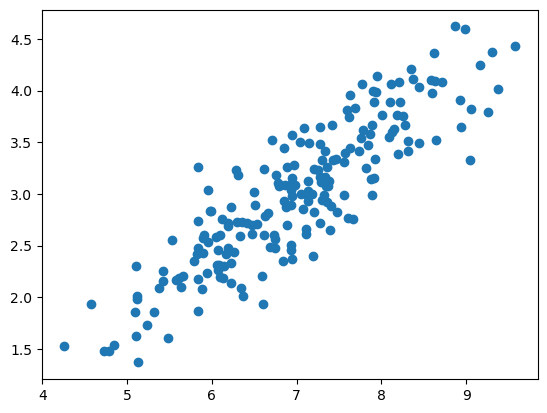

In [98]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [ ]:
from sklearn.metrics import mean_absolute_error , r2_score,mean_squared_error

In [ ]:
y_predict = lr.predict(X_test)
y_predict

In [ ]:
y_test

In [ ]:
print('MAE',mean_absolute_error(y_test,y_predict))

In [99]:
print('MSE',mean_squared_error(y_test,y_predict))

MSE 0.12129235313495523


In [100]:
print('RMSE',np.sqrt(mean_absolute_error(y_test,y_predict)))

RMSE 0.5370950504220062


In [101]:
print('r2_score',r2_score(y_test,y_predict))
r2 = r2_score(y_test,y_predict)

r2_score 0.7807301475103842


In [102]:
# adjusted R2 score   

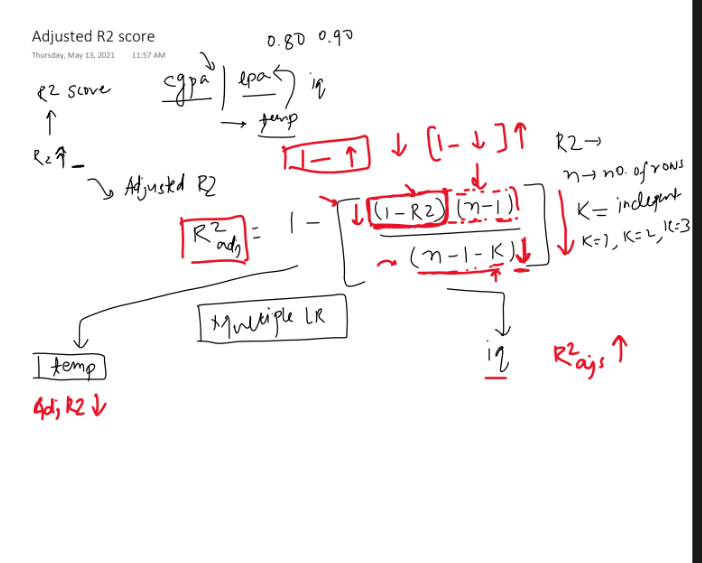

In [103]:
1 - (((1-r2)*(40-1))/(40-1-1))

0.7749598882343417

In [104]:
# yah hum df me ek naya column add karenge aur dekhenge ki 

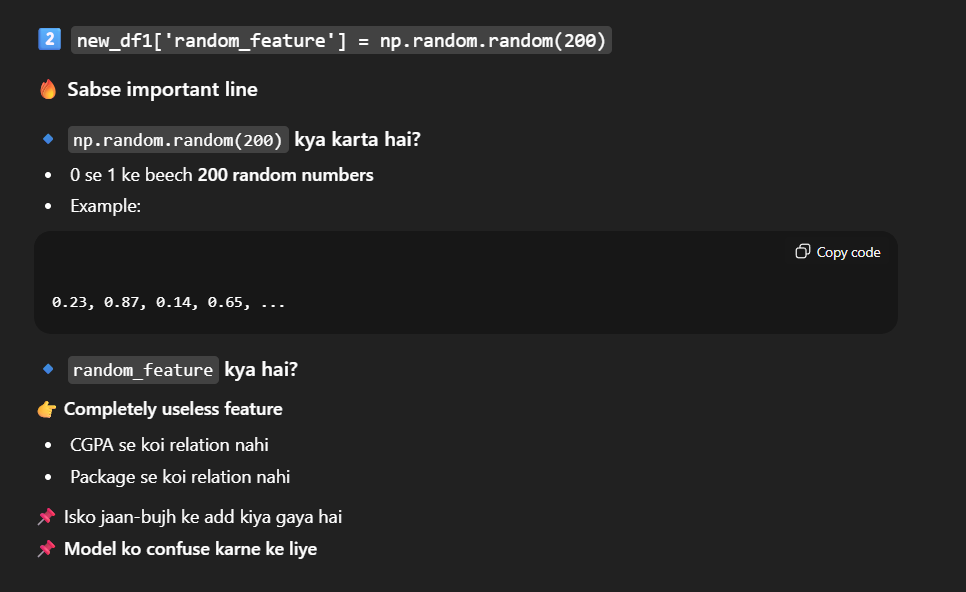

In [105]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.291247,3.26
1,5.12,0.961801,1.98
2,7.82,0.642070,3.25
3,7.42,0.823096,3.67
4,6.94,0.850950,3.57


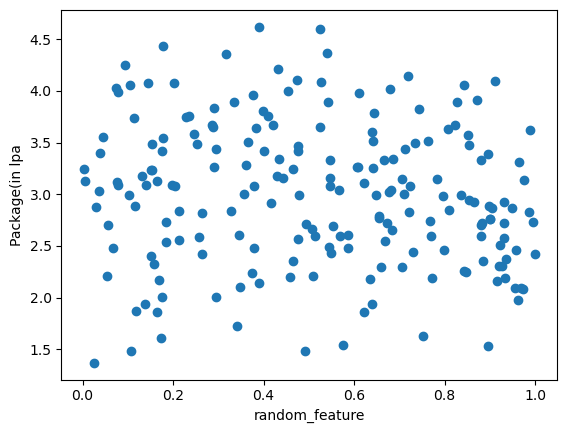

In [106]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa')
plt.show()
# inme koi relation nahi hai but hame koi relevant column add karke (iq) 
# achhe se verify kar sakte hai ki kya difference aata hai 

In [107]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [108]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [109]:
lr = LinearRegression()

In [110]:
lr.fit(X_train,y_train)

LinearRegression()

In [111]:
y_pred = lr.predict(X_test)

In [112]:
print('r2',r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

r2 0.7807366785787512


In [113]:
1 - (((1-r2)*(40-1))/(40-1-1))

0.7749665911729289